In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data.sequencing import data_import
from data.sequencing import data_analysis

# Plot settings
plt.rcParams.update({'font.size': 20, 'svg.fonttype' : 'none', 
                     'figure.figsize' : [15,10], 'xtick.major.size' : 10, 
                     'ytick.major.size' : 10})

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-czv0lgqr because the default path (/tf/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


# Import non-experimental data
This is because there was an issue with the index that I was having trouble with.

In [2]:
seq_2_num = pd.read_csv('dfs.csv')

In [4]:
queries = {'cat' : 'ACCGGTAAGGCACAGAAACG',
           'webb' : 'ATCTGTAAGGCACAAAAACG',
           'dna' : 'ATGTGTAAGGCACAAAAACG',
           'frame' : 'ATACGCAAGGAACAAAAACG',
           'building' : 'ATTTGCAAGGAACAAAAACG',
          'lego' : 'ACCTGTAAGGCACAGAAACG'}

# Get Alignments

In [5]:
q_path = '/tf/primo/mislDrive/alignments/03072023_alignments'
queried_alignments = data_import.import_alignment_summaries(q_path)

bl_path = '/tf/primo/data/experiments/baseline/alignments'
baseline_alignments = data_import.import_alignment_summaries(bl_path)

In [6]:
queried_alignments.keys()

dict_keys(['lego', 'cat', 'webb', 'dna', 'frame', 'building'])

# Apply filters
### Filter out uncut sequences from retrieval experiments and shorter half of strand

In [7]:
df_1 = data_analysis.read_summary(queried_alignments)
df_2 = data_analysis.read_summary(baseline_alignments)
df_combined = pd.concat([df_1, df_2]).reset_index(drop=True)
#df_combined.to_csv("read_summary.csv")
df_combined

,Experiment ID,"First, +","First, -","Second, +","Second, -",Uncut,Unaligned,Total Reads
0,lego,2,17,522879,485,36436,841972,1401791
1,cat,9,196,875839,2644,74532,209001,1162221
2,webb,12,140,795372,6590,109612,170316,1082042
3,dna,13,546,3097077,9109,127756,470967,3705468
4,frame,11,772,2365731,5320,105317,486675,2963826
5,building,7,88,2224025,1888,72982,373512,2672502
6,bl2,0,0,75,136,212323,99466,312000
7,bl3,1,0,23,28,56312,5636,62000
8,bl1,17,1,417,1696,1071839,462935,1536905


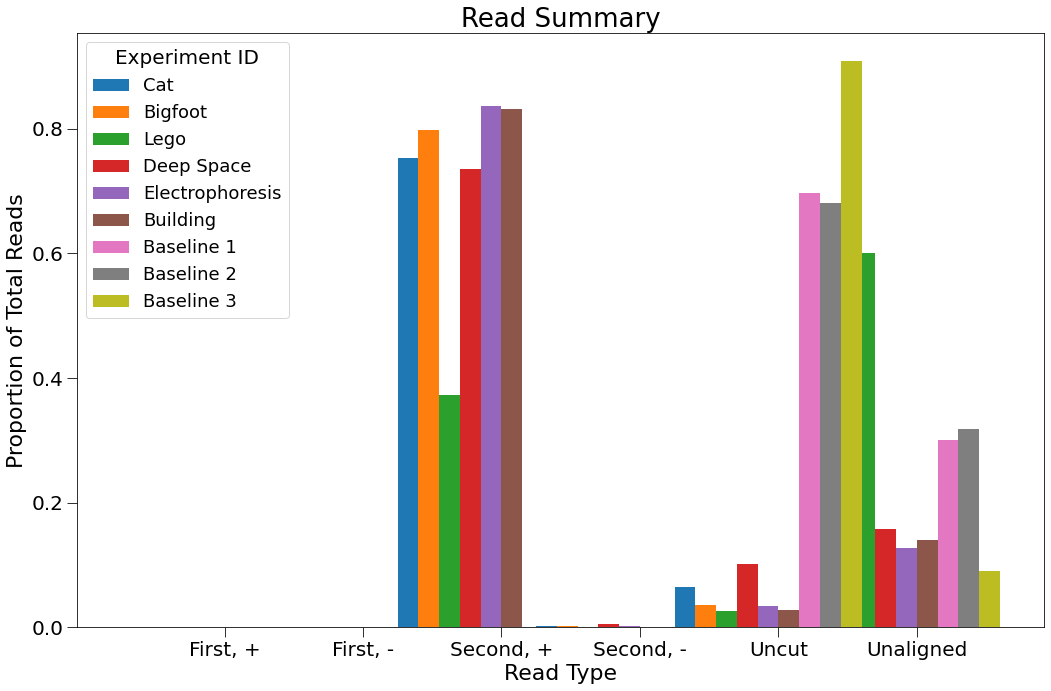

In [9]:
custom_labels = {
    'cat': 'Cat',
    'frame': 'Bigfoot',
    'lego': 'Lego',
    'webb': 'Deep Space',
    'dna': 'Electrophoresis',
    'building': 'Building',
    'bl1': 'Baseline 1',
    'bl2': 'Baseline 2',
    'bl3': 'Baseline 3'
}
df_combined['Experiment ID'] = df_combined['Experiment ID'].map(custom_labels)

# Custom order
custom_order = ['Cat', 'Bigfoot', 'Lego', 'Deep Space', 'Electrophoresis', 'Building', 'Baseline 1', 'Baseline 2', 'Baseline 3']
df_combined['Order'] = df_combined['Experiment ID'].apply(lambda x: custom_order.index(x))
df_combined.sort_values('Order', inplace=True)

# Calculating proportions
read_types = df_combined.columns[1:-2]
experiment_ids = df_combined['Experiment ID'].unique()
positions = np.arange(len(read_types))
width = 0.15
fig, ax = plt.subplots()

for i, exp_id in enumerate(experiment_ids):
    proportions = df_combined.loc[df_combined['Experiment ID'] == exp_id, read_types].values.flatten() / df_combined.loc[df_combined['Experiment ID'] == exp_id, 'Total Reads'].values
    pos = positions - (len(experiment_ids) / 2 - i) * width
    ax.bar(pos, proportions, width, label=exp_id)

ax.set_xticks(positions)
ax.set_xticklabels(read_types)
ax.set_xlabel('Read Type', fontsize=22)
ax.set_ylabel('Proportion of Total Reads', fontsize=22)
ax.set_title('Read Summary', fontsize=26)
plt.legend(title="Experiment ID", fontsize=18, title_fontsize=20)
plt.tight_layout()
#plt.savefig('read_summary.svg', transparent=True , dpi=600, bbox_inches='tight', format='svg')
plt.show()

## Apply filters and record total at each step

In [10]:
all_alignments = {**queried_alignments, **baseline_alignments}
filter_nums = pd.DataFrame()

# Starting lengths
tmp = []
labs = []
for k,v in all_alignments.items():
    tmp.append(len(v))
    labs.append(k)
    
filter_nums['Experiment ID'] = labs
filter_nums['Total Read'] = tmp

# Unaligned filter
tmp = []
all_aligned = {}
for k,v in all_alignments.items():
    all_aligned[k] = v[v['alignment_genome'] != '*']
    tmp.append(len(all_aligned[k]))
filter_nums['Aligned'] = tmp

# Cut type filter for retrieved
tmp = []
all_cut = {}
for k,v in all_aligned.items():
    if 'bl' not in k: 
        all_cut[k] = v[(v['alignment_genome_start'] >= 55) & (v['alignment_direction'] == '+')]
    else:
        all_cut[k] = v
    tmp.append(len(all_cut[k]))
filter_nums['Cut Type'] = tmp

# Filter for alignment accuracy
tmp = []
all_accurate = {}
for k,v in all_cut.items():
    if 'bl' not in k:
        all_accurate[k] = v[v['alignment_accuracy'] >= .9]
    else:
        all_accurate[k] = v
    tmp.append(len(all_accurate[k]))
filter_nums['Accuracy > .9'] = tmp

# Filter low reads in baseline
bl_seqs_to_zero = ['456', '119', '227']
tmp = []
all_accurate2 = {}
for k, v in all_accurate.items():
    all_accurate2[k] = v.loc[~v['alignment_genome'].isin(bl_seqs_to_zero)]
    tmp.append(len(all_accurate2[k]))
filter_nums['Baseline Read Count > 10'] = tmp
filter_nums.to_csv('filter_nums_all.csv')

In [15]:
filter_nums

,Experiment ID,Total Read,Aligned,Cut Type,Accuracy > .9,Baseline Read Count > 10
0,lego,1401791,559819,522918,485972,485966
1,cat,1162221,953220,875890,830908,830860
2,webb,1082042,911726,795423,749728,749723
3,dna,3705468,3234501,3097357,2943453,2943437
4,frame,2963826,2477151,2365961,2239743,2239692
5,building,2672502,2298990,2224205,2150220,2150180
6,bl2,312000,212534,212534,212534,212528
7,bl3,62000,56364,56364,56364,56362
8,bl1,1536905,1073970,1073970,1073970,1073957


In [13]:
filter_nums

,Experiment ID,Total Read,Aligned,Cut Type,Accuracy > .9,Baseline Read Count > 10
0,lego,1401791,559819,522918,485972,485966
1,cat,1162221,953220,875890,830908,830860
2,webb,1082042,911726,795423,749728,749723
3,dna,3705468,3234501,3097357,2943453,2943437
4,frame,2963826,2477151,2365961,2239743,2239692
5,building,2672502,2298990,2224205,2150220,2150180
6,bl2,312000,212534,212534,128899,128896
7,bl3,62000,56364,56364,53323,53322
8,bl1,1536905,1073970,1073970,911987,911978


# Calculate Baseline Enrichments

In [12]:
bl_enrichments = {}
for k,v in all_accurate2.items():
    if 'bl' in k:
        bl_enrichments[k] = data_analysis.summarize_enrichment(v)

# take average of enrichment
bl_avg_enrichment = pd.DataFrame()
bl_avg_enrichment['seq_id'] = bl_enrichments['bl1']['seq_id']
bl_avg_enrichment['bl1_reads'] = bl_enrichments['bl1']['reads']
bl_avg_enrichment['bl2_reads'] = bl_enrichments['bl2']['reads']
bl_avg_enrichment['pool_enrichment'] = (bl_enrichments['bl1']['pool_enrichment'] + bl_enrichments['bl2']['pool_enrichment']) / 2

# add to bl enrichments dict
bl_enrichments['avg'] = bl_avg_enrichment

# Calculate experiment enrichment score

In [13]:
# Also calculate enrichment score for bl3 to use for comparison
exp_enrchmnts = {}
for k,v in all_accurate2.items():
    if 'bl' not in k:
        # Calculate predicted activity
        query = queries[k]
        pred = data_analysis.calc_pred_enrichment(query)
        # Calculate enrichment
        tmp_df = data_analysis.summarize_enrichment(v, bl=bl_enrichments['avg'])
        tmp_df['pred_activity'] = pred
        tmp_df['bl_enrichment'] = bl_enrichments['avg']['pool_enrichment']
        exp_enrchmnts[k] = tmp_df
    if k == 'bl3':
        tmp_df = data_analysis.summarize_enrichment(v, bl=bl_enrichments['avg'])
        # This is arbitrary
        tmp_df['pred_activity'] = pred
        tmp_df['bl_enrichment'] = bl_enrichments['avg']['pool_enrichment']
        exp_enrchmnts[k] = tmp_df

# Save Data

In [14]:
q_path = '/tf/primo/data/experiments/retrieved/enrichments'
bl_path = '/tf/primo/data/experiments/baseline/enrichments'
for k,v in bl_enrichments.items():
    v.to_csv(f'{bl_path}/{k}_new_n9.csv')
    
for k,v in exp_enrchmnts.items():
    v.to_csv(f'{q_path}/{k}_new_n9.csv')